In [1]:
!pip install terratorch

  Using cached terratorch-1.0.2-py3-none-any.whl.metadata (10 kB)
  Using cached torch-2.7.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached torchvision-0.22.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached albumentations-1.4.6-py3-none-any.whl.metadata (37 kB)
  Using cached albucore-0.0.16-py3-none-any.whl.metadata (3.1 kB)
  Using cached torchmetrics-1.7.1-py3-none-any.whl.metadata (21 kB)
  Using cached geopandas-1.0.1-py3-none-any.whl.metadata (2.2 kB)
  Using cached lightly-1.5.20-py3-none-any.whl.metadata (37 kB)
  Using cached jsonargparse-4.35.0-py3-none-any.whl.metadata (12 kB)
  Using cached h5py-3.13.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.5 kB)
  Using cached mlflow-2.22.0-py3-none-any.whl.metadata (30 kB)
  Using cached lightning-2.5.1.post0-py3-none-any.whl.metadata (39 kB)
  Using cached segmentation_models_pytorch-0.4.0-py3-none-any.whl.metadata (32 kB)
  Using cached pytest-8.3.5-py3-none-a

In [2]:
!pip install git+https://github.com/Lightning-AI/pytorch-lightning.git

  Cloning https://github.com/Lightning-AI/pytorch-lightning.git to /tmp/pip-req-build-ket_721c
  Running command git clone --filter=blob:none --quiet https://github.com/Lightning-AI/pytorch-lightning.git /tmp/pip-req-build-ket_721c
  Resolved https://github.com/Lightning-AI/pytorch-lightning.git to commit e088694d411790747af1a52a59a20e6efaa1bebd
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for lightning: filename=lightning-2.6.0.dev0-py3-none-any.whl size=838941 sha256=2bc7d8efe44a66ff98bd9ae4d3edde2c220c9ccf841a74572edcbfc77e9ac496
  Stored in directory: /tmp/pip-ephem-wheel-cache-6f5qdv7h/wheels/20/01/6b/3dea42b7e662c0b851ca4382fac5ca976082dfb21eda9ea9a0
Successfully built lightning
    kubernetes (>=9.0.0a1.0) ; extra == 'all_extras'
               ~~~~~~~~~~^
  Attempting uninstall: lightning
    Found existing instal

In [3]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np 
import xarray as xr
import torch
import rioxarray as rxr
import os
import rasterio
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download
from terratorch.registry import BACKBONE_REGISTRY

import terratorch
import lightning.pytorch as pl

# Select device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

In [4]:
print(torch.cuda.is_available())

True


## Patch Extraction Around Label Points 

In [5]:
ds = xr.open_dataset("./data_FM/s2/s2_2024.nc", engine="h5netcdf")

# attach CRS if not already present
#if not ds.rio.crs:
#    ds = ds.rio.write_crs("EPSG:3832")

ds

/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray_sentinel/esa_safe.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


<xarray.Dataset> Size: 53GB
Dimensions:          (time: 1, y: 19200, x: 28800)
Coordinates:
  * y                (y) float64 154kB -1.888e+06 -1.888e+06 ... -2.08e+06
  * x                (x) float64 230kB 2.952e+06 2.952e+06 ... 3.24e+06 3.24e+06
    spatial_ref      int32 4B ...
  * time             (time) datetime64[ns] 8B 2024-01-01
Data variables:
    COASTAL_AEROSOL  (time, y, x) float64 4GB ...
    BLUE             (time, y, x) float64 4GB ...
    GREEN            (time, y, x) float64 4GB ...
    RED              (time, y, x) float64 4GB ...
    RED_EDGE_1       (time, y, x) float64 4GB ...
    RED_EDGE_2       (time, y, x) float64 4GB ...
    RED_EDGE_3       (time, y, x) float64 4GB ...
    NIR_BROAD        (time, y, x) float64 4GB ...
    NIR_NARROW       (time, y, x) float64 4GB ...
    CIRRUS           (time, y, x) float64 4GB ...
    SWIR_1           (time, y, x) float64 4GB ...
    SWIR_2           (time, y, x) float64 4GB ...

In [6]:
fc = xr.open_dataset("./data_FM/fc/fc_2024.nc", engine="h5netcdf")


fc

<xarray.Dataset> Size: 304MB
Dimensions:      (time: 1, y: 4261, x: 5938)
Coordinates:
  * y            (y) float64 34kB -1.931e+06 -1.932e+06 ... -2.059e+06
  * x            (x) float64 48kB 3.028e+06 3.028e+06 ... 3.206e+06 3.206e+06
    spatial_ref  int32 4B ...
  * time         (time) datetime64[ns] 8B 2024-01-01
Data variables:
    bs_pc_50     (time, y, x) float32 101MB ...
    pv_pc_50     (time, y, x) float32 101MB ...
    npv_pc_50    (time, y, x) float32 101MB ...

In [7]:
points = pd.read_csv("./data_FM/label/label.csv")  
# Group by class_id and sample

points = (
    points.groupby("class_id", group_keys=False)
    .apply(lambda x: x.sample(n=1000, random_state=42) if len(x) > 1000 else x)
)

print(points["class_id"].value_counts())

class_id
1    1000
3    1000
7    1000
2     916
4     180
6     136
5      39
Name: count, dtype: int64


/tmp/ipykernel_387/3439984927.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=1000, random_state=42) if len(x) > 1000 else x)


In [8]:
# build GeoDataFrame
gdf = gpd.GeoDataFrame(points, geometry=gpd.points_from_xy(points.lon, points.lat), crs="EPSG:4326")

# reproject to match S2 CRS
gdf = gdf.to_crs(ds.rio.crs)

X, Y = [], []
patch_size = 32
half = patch_size // 2

for _, row in gdf.iterrows():
    label = row["class_id"]
    x = row.geometry.x
    y = row.geometry.y
    
    # find nearest pixel indices
    ref_band = ds["RED"]
    x_res = float((ref_band.x[1] - ref_band.x[0]).item())
    y_res = float((ref_band.y[1] - ref_band.y[0]).item())
    
    x0 = float(ref_band.x[0].item())
    y0 = float(ref_band.y[0].item())

    px = int((x - x0) / x_res)
    py = int((y - y0) / y_res)
        
    # extract patch around the point
    patch = ds.isel(
        x=slice(px-half, px+half),
        y=slice(py-half, py+half),
        time=0
    ).to_array().transpose("y", "x", "variable").values

    #if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
    #    X.append(patch)
    #    Y.append(label)
     # If patch is smaller than patch_size -> pad with NaN
    h, w, c = patch.shape
    if h != patch_size or w != patch_size:
        padded = np.full((patch_size, patch_size, c), np.nan, dtype=np.float32)
        padded[:h, :w, :] = patch
        patch = padded
        
    # Append
    X.append(patch)
    Y.append(label)



    
# stack final dataset
X = np.stack(X)
Y = np.array(Y)
print("Final dataset:", X.shape, Y.shape)



Final dataset: (4271, 32, 32, 12) (4271,)


In [9]:
X_fc, Y_fc = [], []
patch_size = 32
half = patch_size // 2

for _, row in gdf.iterrows():
    label = row["class_id"]
    x = row.geometry.x
    y = row.geometry.y
    
    # find nearest pixel indices
    ref_band = fc["bs_pc_50"]
    x_res = float((ref_band.x[1] - ref_band.x[0]).item())
    y_res = float((ref_band.y[1] - ref_band.y[0]).item())
    
    x0 = float(ref_band.x[0].item())
    y0 = float(ref_band.y[0].item())

    px = int((x - x0) / x_res)
    py = int((y - y0) / y_res)
        
    # extract patch around the point
    patch = fc.isel(
        x=slice(px-half, px+half),
        y=slice(py-half, py+half),
        time=0
    ).to_array().transpose("y", "x", "variable").values

    #if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
    #    X.append(patch)
    #    Y.append(label)
     # If patch is smaller than patch_size -> pad with NaN
    h, w, c = patch.shape
    if h != patch_size or w != patch_size:
        padded = np.full((patch_size, patch_size, c), np.nan, dtype=np.float32)
        padded[:h, :w, :] = patch
        patch = padded
        
    # Append
    X_fc.append(patch)
    Y_fc.append(label)



    
# stack final dataset
X_fc = np.stack(X_fc)
Y_fc = np.array(Y_fc)
print("Final dataset:", X_fc.shape, Y_fc.shape)


Final dataset: (4271, 32, 32, 3) (4271,)


In [18]:
# Find the first index where the array is not all NaN
for i in range(len(X_fc)):
    if np.any(~np.isnan(X_fc[i])):
        print("First non-null index:", i)
        break

First non-null index: 0


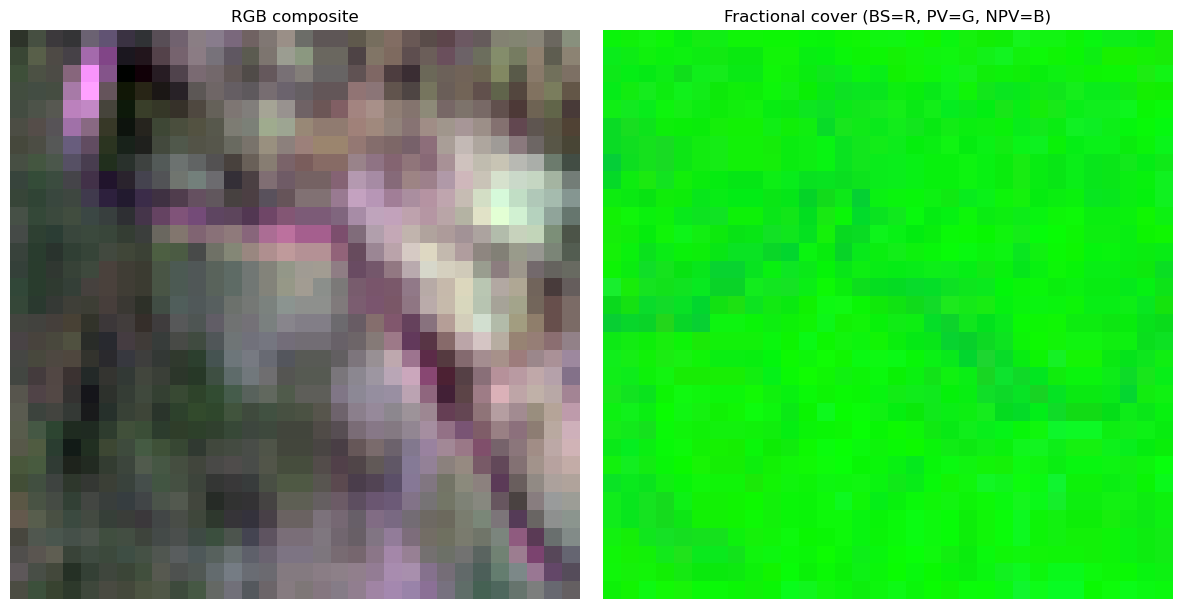

Class_id : 1


In [24]:
idx = 0

# --- RGB ---
rgb = X[idx, :, :, [1, 2, 3]]
rgb = np.transpose(rgb, (1, 2, 0))
rgb_norm = (rgb - rgb.min(axis=(0,1))) / (rgb.max(axis=(0,1)) - rgb.min(axis=(0,1)))

# --- Fractional Cover ---

fc = X_fc[idx].astype(float)
fc_norm = (fc - fc.min()) / (fc.max() - fc.min())


# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# RGB
axs[0].imshow(rgb_norm)
axs[0].set_title("RGB composite")
axs[0].axis("off")

# Fractional cover (stacked RGB: BS=R, PV=G, NPV=B)
axs[1].imshow(fc_norm)  
axs[1].set_title("Fractional cover (BS=R, PV=G, NPV=B)")
axs[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Class_id : {Y[idx]}")

In [26]:
from rasterio.transform import from_origin
from sklearn.model_selection import train_test_split
import shutil

# Prepare folders
base_path_s2 = "./data_FM/s2/patch"
base_path_fc = "./data_FM/fc/patch"
folders = ["train", "validation", "test"]

for f in folders:
    # Sentinel-2
    x_dir = os.path.join(base_path_s2, f, "X")
    y_dir = os.path.join(base_path_s2, f, "y")
    if os.path.exists(x_dir):
        shutil.rmtree(x_dir)
    if os.path.exists(y_dir):
        shutil.rmtree(y_dir)
    os.makedirs(x_dir, exist_ok=True)
    os.makedirs(y_dir, exist_ok=True)

    # FC
    x_dir = os.path.join(base_path_fc, f, "X")
    y_dir = os.path.join(base_path_fc, f, "y")
    if os.path.exists(x_dir):
        shutil.rmtree(x_dir)
    if os.path.exists(y_dir):
        shutil.rmtree(y_dir)
    os.makedirs(x_dir, exist_ok=True)
    os.makedirs(y_dir, exist_ok=True)

# Train/validation/test split
indices = np.arange(len(Y))

train_idx, temp_idx, _, temp_y = train_test_split(
    indices, Y, test_size=0.3, random_state=42, stratify=Y
)
val_idx, test_idx, _, _ = train_test_split(
    temp_idx, temp_y, test_size=0.5, random_state=42, stratify=temp_y
)

splits = {
    "train": (X[train_idx], X_fc[train_idx], Y[train_idx]),
    "validation": (X[val_idx], X_fc[val_idx], Y[val_idx]),
    "test": (X[test_idx], X_fc[test_idx], Y[test_idx]),
}


# Function to save patches and labels
def save_patches_and_labels(X_rgb, X_fc, y_data, folder, ref_ds, start_idx=0,
                            base_path_rgb="./data_FM/s2/patch",
                            base_path_fc="./data_FM/fc/patch"):
    """
    Save RGB and FC patches with consistent indexing.
    Rule:
      - Skip patch if RGB is fully NaN
      - Keep FC even if it is fully NaN, as long as RGB is valid
    """
    for i in range(X_rgb.shape[0]):
        rgb_patch = X_rgb[i]  # (H, W, C)
        fc_patch = X_fc[i]    # (H, W, 3)

        # --- Skip if RGB is fully NaN ---
        if np.isnan(rgb_patch).all():
            continue

        label = int(y_data[i])

        # Compute transform (same for both)
        transform = from_origin(
            ref_ds.x[0], ref_ds.y[0],
            ref_ds.x[1] - ref_ds.x[0],
            ref_ds.y[1] - ref_ds.y[0]
        )

        # --- Save RGB ---
        rgb_tif = np.transpose(rgb_patch, (2, 0, 1)).astype(np.float32)
        rgb_name = f"patch_{start_idx}.tif"
        rgb_path = os.path.join(base_path_rgb, folder, "X", rgb_name)

        with rasterio.open(
            rgb_path,
            "w",
            driver="GTiff",
            height=rgb_tif.shape[1],
            width=rgb_tif.shape[2],
            count=rgb_tif.shape[0],
            dtype=rgb_tif.dtype,
            crs=ref_ds.rio.crs,
            transform=transform
        ) as dst:
            dst.write(rgb_tif)

        # --- Save FC ---
        fc_tif = np.transpose(fc_patch, (2, 0, 1)).astype(np.float32)
        fc_name = f"patch_{start_idx}.tif"
        fc_path = os.path.join(base_path_fc, folder, "X", fc_name)

        with rasterio.open(
            fc_path,
            "w",
            driver="GTiff",
            height=fc_tif.shape[1],
            width=fc_tif.shape[2],
            count=fc_tif.shape[0],
            dtype=fc_tif.dtype,
            crs=ref_ds.rio.crs,
            transform=transform
        ) as dst:
            dst.write(fc_tif)

        # --- Save label ---
        label_path = os.path.join(base_path_rgb, folder, "y", f"patch_{start_idx}.npy")
        np.save(label_path, np.int64(label - 1))

        start_idx += 1  # increment only for kept patches

    return start_idx

# ----------------------------
# Save all splits
# ----------------------------
idx = 0
for split_name, (X_rgb, X_fc, y_split) in splits.items():
    idx = save_patches_and_labels(X_rgb, X_fc, y_split, folder=split_name, ref_ds=ds, start_idx=idx,
                                  base_path_rgb=base_path_s2, base_path_fc=base_path_fc)


print("All patches saved as GeoTIFFs and labels as individual .npy files!")


All patches saved as GeoTIFFs and labels as individual .npy files!


## DataModule

In [39]:
from terratorch.datamodules import GenericMultiModalDataModule
from terratorch.datasets import HLSBands
import albumentations
 
means_s2 =  [552.718999370115,  484.8719967160565, 433.9346638590377, 316.3900839793572,
         469.25199832373283, 871.1042874274902, 1024.9359711715927, 1009.2936936191497,
         1086.911774081049, 1124.2445565103412, 605.7109925118053, 381.36809126513026]
    
stds_s2 = [145.54868896986773, 144.38050083057266, 210.67528892966706,149.06802623379457,
     348.483274100733, 1138.4244205601822, 1418.5631591657962, 1436.4316526820455,
     1554.5003736521303, 1512.1907882341973, 686.4458048015823, 317.47588132709575]

means_fc = [7.357245445251465, 75.06333923339844, 14.884675025939941]
stds_fc = [4.740213394165039, 14.439167976379395, 12.283880233764648]

my_bands_s2 = [
    'COASTAL_AEROSOL', 'BLUE', 'GREEN', 'RED',
    'RED_EDGE_1', 'RED_EDGE_2', 'RED_EDGE_3',
    'NIR_BROAD', 'NIR_NARROW', 'CIRRUS', 'SWIR_1', 'SWIR_2'
]

my_bands_fc = ["bs_pc_50", "pv_pc_50", "npv_pc_50"]


datamodule = GenericMultiModalDataModule(
    task="classification",
    batch_size=16,
    num_workers=4,
    num_classes=7,

    # Define your input modalities. The names must match the keys in the following dicts.
    modalities=["S2L2A", "fc"],

    rgb_modality="S2L2A",  # Used for plotting. Defaults to the first modality if not provided.
    rgb_indices=[3,2,1],  # RGB channel positions in the rgb_modality.

    # Define data paths as dicts using the modality names as keys.
    train_data_root={
        "S2L2A": "./data_FM/s2/patch/train/X",
        "fc" : "./data_FM/fc/patch/train/X",
    },
    train_label_data_root="./data_FM/s2/patch/train/y",
    val_data_root={
        "S2L2A": "./data_FM/s2/patch/validation/X",
        "fc": "./data_FM/fc/patch/validation/X",
    },
    val_label_data_root="./data_FM/s2/patch/validation/y",
    test_data_root={
        "S2L2A":"./data_FM/s2/patch/test/X",
        "fc":"./data_FM/fc/patch/test/X",
    },
    test_label_data_root="./data_FM/s2/patch/test/y",

    
    # Define suffix, again using dicts.
    img_grep={
        "S2L2A": "*.tif",
        "fc": "*.tif",
    },
    label_grep="*.npy",
    
    # With TerraTorch, you can select a subset of the dataset bands as model inputs by providing dataset_bands (all bands in the data) and output_bands (selected bands). This setting is optional for all modalities and needs to be provided as dicts.
    # Here is an example for with S-1 GRD. You could change the output to ["VV"] to only train on the first band. Note that means and stds must be aligned with the output_bands (equal length of values). 
    dataset_bands={
        "S2L2A": my_bands_s2,
        "fc": my_bands_fc,
    },
    output_bands={
        "S2L2A": my_bands_s2,
        "fc": my_bands_fc,
    },


    # Define standardization values. We use the pre-training values here and providing the additional modalities is not a problem, which makes it simple to experiment with different modality combinations. Alternatively, use the dataset statistics that you can generate using `terratorch compute_statistics -c config.yaml` (requires concat_bands: true for this multimodal datamodule).
    means={
        "S2L2A": means_s2,
        "fc": means_fc,
    },
    stds={
        "S2L2A": stds_s2,
        "fc": stds_fc,
    },
    
    
    no_label_replace=-1,  # Replace NaN labels. defaults to -1 which is ignored in the loss and metrics.
    no_data_replace=0,  # Replace NaN data
)
# we want to access some properties of the train dataset later on, so lets call setup here
# if not, we would not need to
datamodule.setup("fit")


In [28]:
# checking datasets validation split size
val_dataset = datamodule.train_dataset
len(val_dataset)

2083

In [29]:
datamodule.setup("test")
test_dataset = datamodule.test_dataset
len(test_dataset)

460

In [8]:
from sklearn.utils.class_weight import compute_class_weight


y_train_list = []

for i in range(len(datamodule.train_dataset)):
    label = datamodule.train_dataset[i]  
    y_train_list.append(label['label'])       

y_train_flat = np.array(y_train_list)

y_train_flat = y_train_flat[y_train_flat != -1]

classes = np.arange(datamodule.num_classes)
weights = compute_class_weight("balanced", classes=classes, y=y_train_flat)
weights = torch.tensor(weights, dtype=torch.float32)

print("Class weights:", weights)

Class weights: tensor([ 0.5636,  0.6763,  0.5701,  3.0677, 11.0212,  3.5008,  0.7749])


## Model

In [30]:
from terratorch.registry import BACKBONE_REGISTRY, TERRATORCH_BACKBONE_REGISTRY, TERRATORCH_DECODER_REGISTRY

In [40]:
import shutil
def empty_folder(folder_path: str):
    """Remove all files and subfolders inside a folder, but keep the folder itself."""
    if os.path.exists(folder_path):
        for item in os.listdir(folder_path):
            item_path = os.path.join(folder_path, item)
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
    else:
        os.makedirs(folder_path)  # Create if missing

# Usage
empty_folder("./data_FM/output/")

In [41]:
# Print all TerraMind v1 backbones.  
[backbone   
 for backbone in TERRATORCH_BACKBONE_REGISTRY
 if 'terramind_v1' in backbone]

['terramind_v1_base',
 'terramind_v1_base_tim',
 'terramind_v1_large',
 'terramind_v1_large_tim']

In [43]:
model = BACKBONE_REGISTRY.build(
    "terramind_v1_base",
    modalities=["S2L2A", 
               {"fc" : 3}],
    pretrained=True,
)
model

Weights for encoder_embeddings.fc.proj.weight are missing in state dict, using random initialization.
Weights for encoder_embeddings.fc.mod_emb are missing in state dict, using random initialization.
Weights for encoder_embeddings.fc.pos_emb are missing in state dict, using random initialization.


TerraMindViT(
  (encoder_embeddings): ModuleDict(
    (untok_sen2l2a@224): ImageEncoderEmbedding(
      (proj): Linear(in_features=3072, out_features=768, bias=False)
    )
    (fc): ImageEncoderEmbedding(
      (proj): Linear(in_features=768, out_features=768, bias=False)
    )
  )
  (encoder): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm()
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=False)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm()
      (mlp): GatedMlp(
        (fc1): Linear(in_features=768, out_features=2048, bias=False)
        (act): SiLU()
        (fc2): Linear(in_features=2048, out_features=768, bias=False)
        (fc3): Linear(in_features=768, out_features=2048, bias=False)
      )
    )
  )
  (encoder_norm): LayerNorm()
)

In [36]:
class LossHistoryCallback(pl.Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.train_f1s = []
        self.val_f1s = []

    def on_fit_start(self, trainer, pl_module):
        # Reset everything at the start of training
        self.train_losses = []
        self.val_losses = []
        self.train_f1s = []
        self.val_f1s = []

    def on_train_epoch_end(self, trainer, pl_module):
        # Store train loss
        avg_loss = trainer.callback_metrics.get("train/loss")
        if avg_loss is not None:
            self.train_losses.append(avg_loss.item())

        # Store train F1
        avg_f1 = trainer.callback_metrics.get("train/Multiclass_F1_Score")
        if avg_f1 is not None:
            self.train_f1s.append(avg_f1.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        # Store validation loss
        val_loss = trainer.callback_metrics.get("val/loss")
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

        # Store validation F1
        val_f1 = trainer.callback_metrics.get("val/Multiclass_F1_Score")
        if val_f1 is not None:
            self.val_f1s.append(val_f1.item())


loss_history = LossHistoryCallback()

In [45]:
from torchmetrics import F1Score
pl.seed_everything(0)

# By default, TerraTorch saves the model with the best validation loss. You can overwrite this by defining a custom ModelCheckpoint, e.g., saving the model with the highest validation mIoU.  
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath="./data_FM/output/terramind_base/checkpoints/",
    mode="min",
    monitor="val/loss", # Variable to monitor
    filename="best-loss",
    save_weights_only=True,
)


checkpoint_f1 = pl.callbacks.ModelCheckpoint(
    dirpath="./data_FM/output/terramind_base/checkpoints_f1/",
    monitor="val/Multiclass_F1_Score",
    mode="max",
    filename="best-f1",
    save_weights_only=True,
)

# Lightning Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices=1, # Deactivate multi-gpu because it often fails in notebooks
    precision="bf16-mixed",  # delete for full precision training.
    num_nodes=1,
    logger=True,  # Uses TensorBoard by default
    max_epochs=50,
    log_every_n_steps=1,
    callbacks=[checkpoint_callback, checkpoint_f1, pl.callbacks.RichProgressBar(), loss_history],
    default_root_dir="./data_FM/output/",
    num_sanity_val_steps=0,
)


# Segmentation mask that build the model and handles training and validation steps.  
model = terratorch.tasks.ClassificationTask(
    model_factory="EncoderDecoderFactory",  # Combines a backbone with necks, the decoder, and a head
    model_args={
        # TerraMind backbone
        "backbone": "terramind_v1_base", # large version: terramind_v1_large 
        "backbone_pretrained": True,
        "backbone_modalities": ["S2L2A", {"fc" : 3}],
       "necks": [
            {"name": "SelectIndices", "indices": [2, 5, 8, 11]}, 
            {"name": "ReshapeTokensToImage", "remove_cls_token": False},  
        ],

        # Decoder
        "decoder": "IdentityDecoder",
        #"decoder_num_convs": 4,
        #"decoder_channels": 256,
        
        "num_classes": 7,
        "head_dropout": 0.1,
    },
    loss="ce",
    #class_weights=weights,    
    optimizer="AdamW",
    lr = 1e-4,
    optimizer_hparams={
        "weight_decay": 0.01,
    },  
    scheduler="ReduceLROnPlateau",
    scheduler_hparams={
        "factor": 0.5,
        "patience": 5,
    },
    
    ignore_index=-1,
    freeze_backbone=True, # Only used to speed up fine-tuning in this demo, we highly recommend fine-tuning the backbone for the best performance. 
    freeze_decoder=True, 
    freeze_head = False,
    class_names=["Forest", "Grassland", "Cropland", "Buildup", "Baresoil", "Water", "Mangroves"],
)

Seed set to 0
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Weights for encoder_embeddings.fc.proj.weight are missing in state dict, using random initialization.
Weights for encoder_embeddings.fc.mod_emb are missing in state dict, using random initialization.
Weights for encoder_embeddings.fc.pos_emb are missing in state dict, using random initialization.


## Training 

In [46]:
trainer.fit(model, datamodule=datamodule)

You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/srv/conda/envs/notebook/lib/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ScalarOutputModel │ 87.9 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss  │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection  │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection  │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList        │      0 │ train │     0 │
└───┴───────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 5.4 K                                                                                            
Non-trainable params: 87.9 M                                                                                       
Total params: 87.9 M                                                                                               
Total estimated model params size (MB): 351                                                                        
Modules in train mode: 216                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/srv/conda/envs/notebook/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The 
``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, 
as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

/srv/conda/envs/notebook/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The 
``compute`` method of metric MulticlassJaccardIndex was called before the ``update`` method which may lead to 
errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

`Trainer.fit` stopped: `max_epochs=50` reached.


In [47]:
print("Best checkpoint path:", checkpoint_callback.best_model_path)

# Print the best monitored metric value
print("Best val/loss:", checkpoint_callback.best_model_score)

Best checkpoint path: /home/jovyan/fc/data_FM/output/terramind_base/checkpoints/best-loss.ckpt
Best val/loss: tensor(1.1914, device='cuda:0')


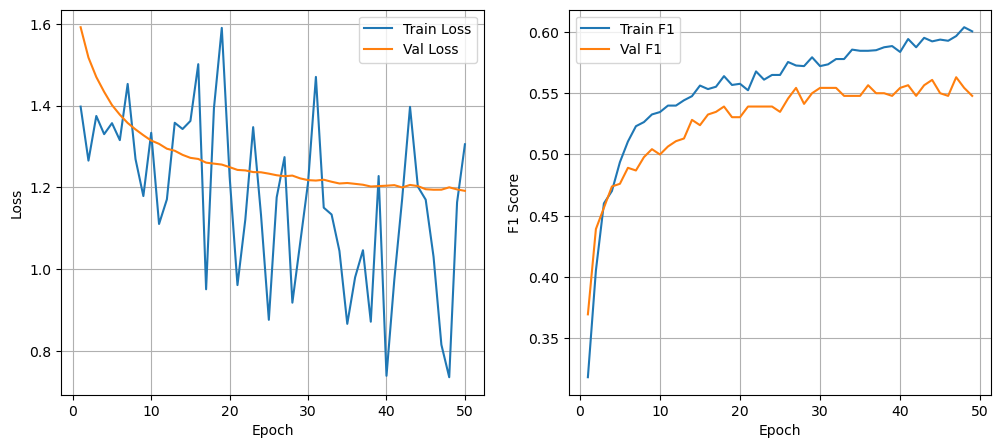

In [48]:
epochs = range(1, len(loss_history.train_losses)+1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, loss_history.train_losses, label="Train Loss")
plt.plot(epochs, loss_history.val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# F1
epochs = range(1, len(loss_history.train_f1s)+1)
plt.subplot(1,2,2)
plt.plot(epochs, loss_history.train_f1s, label="Train F1")
plt.plot(epochs, loss_history.val_f1s, label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)

plt.show()


## Testing

In [49]:
# Let's test the fine-tuned model
best_ckpt_path = "./data_FM/output/terramind_base/checkpoints/best-loss.ckpt"
trainer.test(model, datamodule=datamodule, ckpt_path=best_ckpt_path)


Restoring states from the checkpoint path at ./data_FM/output/terramind_base/checkpoints/best-loss.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at ./data_FM/output/terramind_base/checkpoints/best-loss.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃              Test metric              ┃             DataLoader 0              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/Average_Accuracy         │          0.4141782522201538           │
│       test/Multiclass_F1_Score        │          0.6000000238418579           │
│     test/Multiclass_Jaccard_Index     │           0.305228054523468           │
│         test/Overall_Accuracy         │          0.6000000238418579           │
│               test/loss               │           1.103737473487854           │
│   test/multiclassaccuracy_Baresoil    │                  0.0                  │
│    test/multiclassaccuracy_Buildup    │          0.1304347813129425           │
│   test/multiclassaccuracy_Cropland    │                  0.5                  │
│    test/multiclassaccuracy_Forest     │          0.8225806355476379           │
│   test/multiclassaccuracy_Grassland   │          0.5490196347236633           │
│   test/multiclassaccuracy_Mangroves   │          0.6829268336296082           │
│     test/multiclassaccuracy_Water     │          0.2142857164144516           │
│ test/multiclassjaccardindex_Baresoil  │                  0.0                  │
│  test/multiclassjaccardindex_Buildup  │          0.1304347813129425           │
│ test/multiclassjaccardindex_Cropland  │          0.4000000059604645           │
│  test/multiclassjaccardindex_Forest   │           0.497560977935791           │
│ test/multiclassjaccardindex_Grassland │          0.3660130798816681           │
│ test/multiclassjaccardindex_Mangroves │          0.5283018946647644           │
│   test/multiclassjaccardindex_Water   │          0.2142857164144516           │
└───────────────────────────────────────┴───────────────────────────────────────┘

[{'test/loss': 1.103737473487854,
  'test/Average_Accuracy': 0.4141782522201538,
  'test/multiclassaccuracy_Forest': 0.8225806355476379,
  'test/multiclassaccuracy_Grassland': 0.5490196347236633,
  'test/multiclassaccuracy_Cropland': 0.5,
  'test/multiclassaccuracy_Buildup': 0.1304347813129425,
  'test/multiclassaccuracy_Baresoil': 0.0,
  'test/multiclassaccuracy_Water': 0.2142857164144516,
  'test/multiclassaccuracy_Mangroves': 0.6829268336296082,
  'test/Multiclass_F1_Score': 0.6000000238418579,
  'test/Multiclass_Jaccard_Index': 0.305228054523468,
  'test/multiclassjaccardindex_Forest': 0.497560977935791,
  'test/multiclassjaccardindex_Grassland': 0.3660130798816681,
  'test/multiclassjaccardindex_Cropland': 0.4000000059604645,
  'test/multiclassjaccardindex_Buildup': 0.1304347813129425,
  'test/multiclassjaccardindex_Baresoil': 0.0,
  'test/multiclassjaccardindex_Water': 0.2142857164144516,
  'test/multiclassjaccardindex_Mangroves': 0.5283018946647644,
  'test/Overall_Accuracy': 0.

In [91]:
import matplotlib.pyplot as plt

def plot_classification_sample(sample, band_indices=(3, 2, 1)):
    """
    Plot a classification sample.
    
    Args:
        sample (dict): Contains 'image', 'mask', 'prediction'.
        band_indices (tuple): Which bands to use for RGB display (default: Sentinel-2 RGB = (3,2,1)).
    """
    img = sample["image"].numpy()  # (C, H, W)
    img = img[band_indices, :, :]  # pick RGB bands
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)  # normalize 0-1
    img = img.transpose(1, 2, 0)  # (H, W, C)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    
    ax[0].imshow(img)
    ax[0].set_title("Input image")
    ax[0].axis("off")

    ax[1].imshow([[sample["mask"].item()]], cmap="tab10", vmin=0, vmax=9)
    ax[1].set_title(f"True label: {sample['mask'].item()}")
    ax[1].axis("off")

    ax[2].imshow([[sample["prediction"].item()]], cmap="tab10", vmin=0, vmax=9)
    ax[2].set_title(f"Predicted: {sample['prediction'].item()}")
    ax[2].axis("off")

    plt.show()


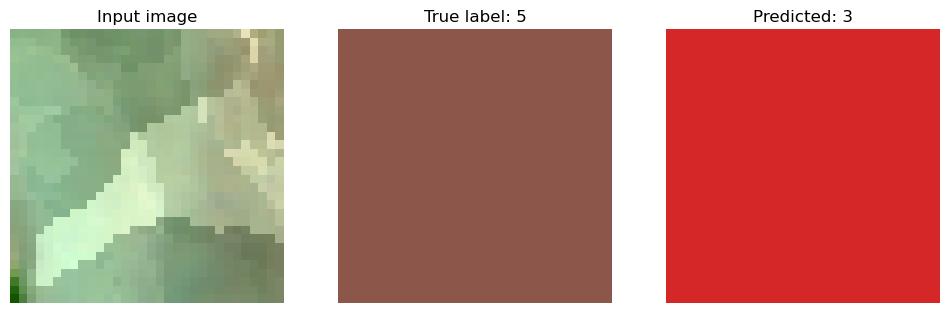

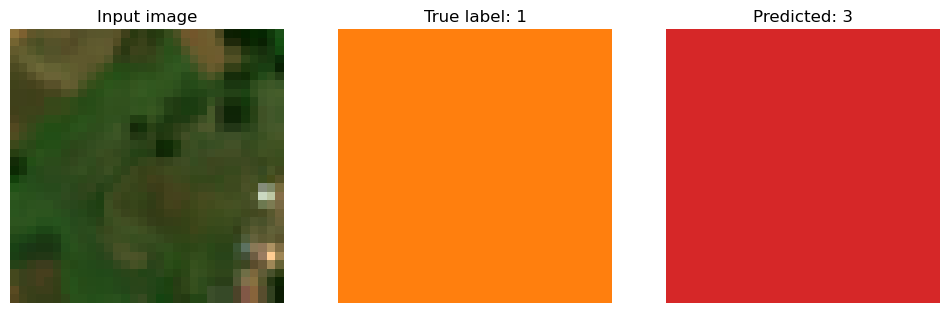

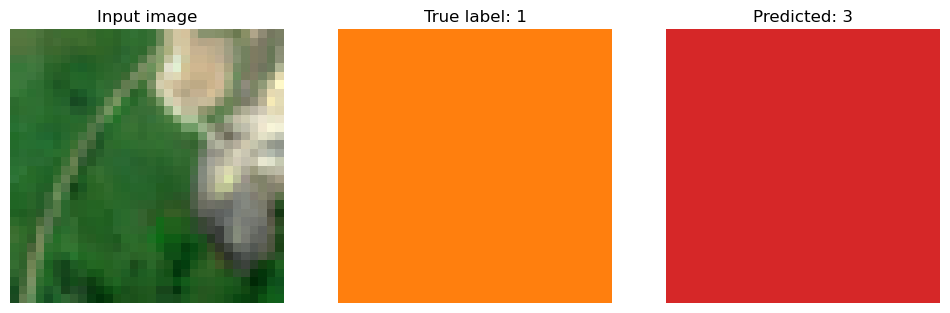

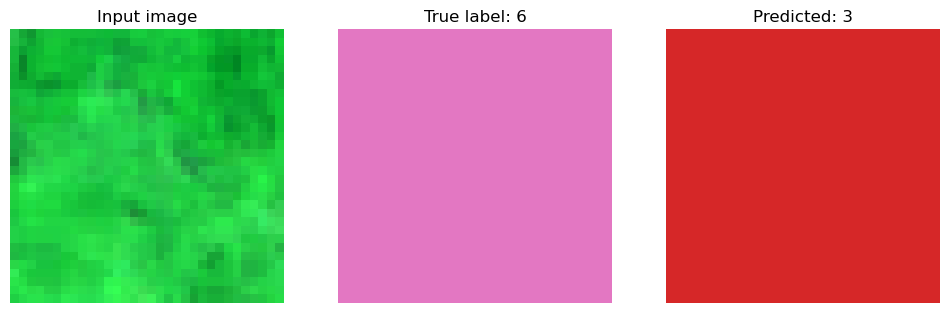

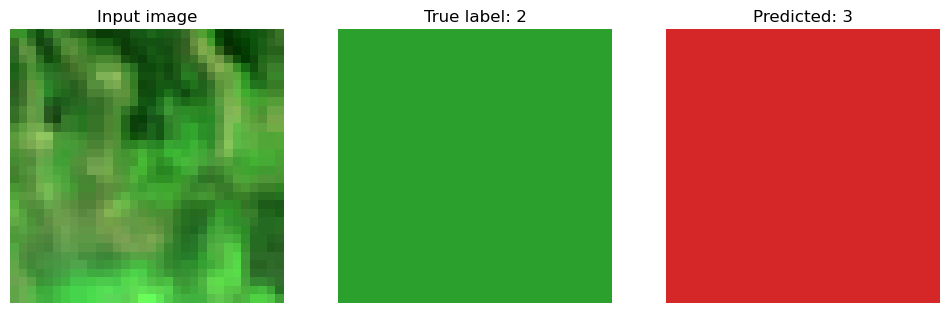

In [92]:
# Now we can use the model for predictions and plotting
model = terratorch.tasks.ClassificationTask.load_from_checkpoint(
    best_ckpt_path,
    model_factory=model.hparams.model_factory,
    model_args=model.hparams.model_args,
)

test_loader = datamodule.test_dataloader()
with torch.no_grad():
    batch = next(iter(test_loader))
    images = batch["image"]
    for mod, value in images.items():
        images[mod] = value.to(model.device)
    masks = batch["label"].numpy()

    with torch.no_grad():
        outputs = model(images)
    
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

for i in range(5):
    sample = {
        "image": batch["image"]["S2L2A"][i].cpu(),
        "mask": batch["label"][i].cpu(),
        "prediction": preds[i],
    }
    plot_classification_sample(sample)
    